In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

File successfully found at: /kaggle/input/datasets/ankicob9/super-store-sales-analysis/Superstore Sales.xlsx

=================== EXECUTIVE SUMMARY ===================
Total Revenue:     $2,297,200.86
Total Profit:      $286,397.02
Total Orders:      5,009



/tmp/ipykernel_58/2820680963.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_subcat, x='Sales', y='Sub-Category', ax=axes[1, 1], palette='viridis')


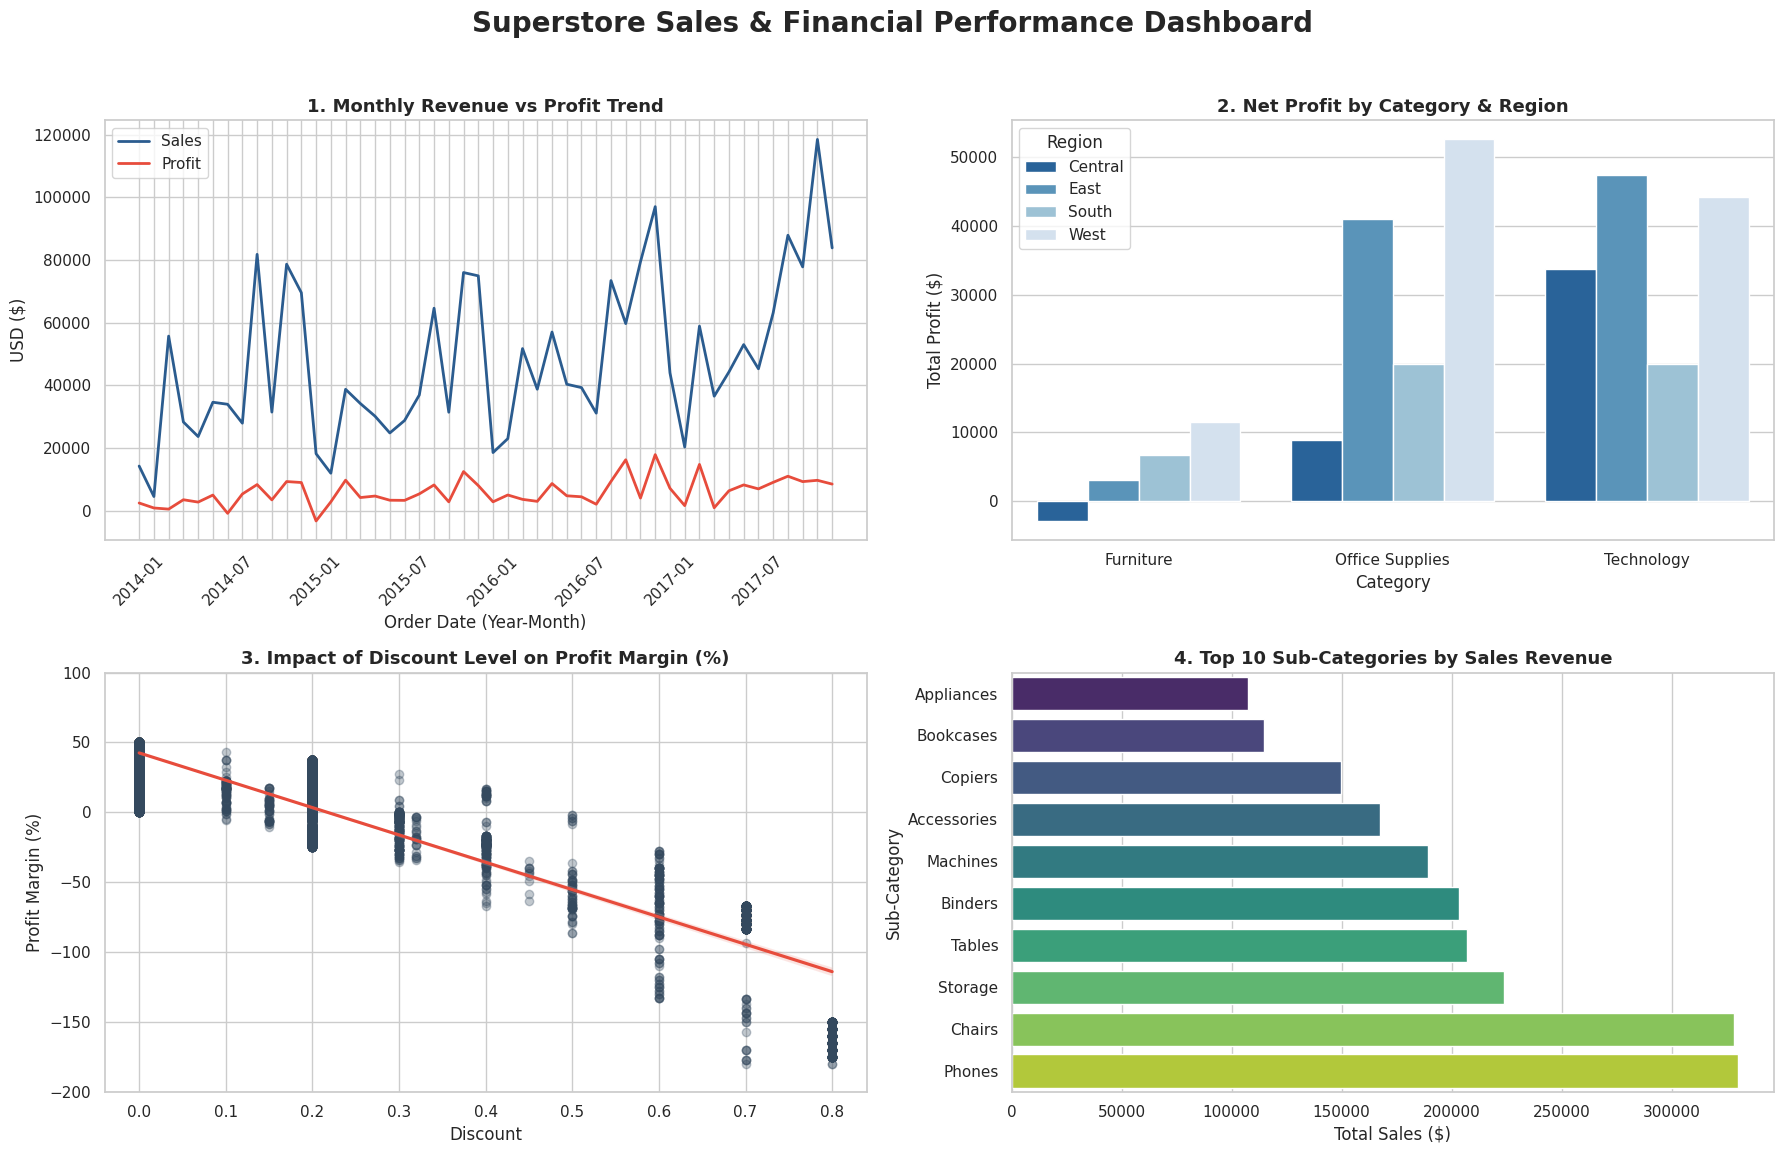

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dynamically locate 'Superstore Sales.xlsx' inside Kaggle input directory
file_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('Superstore Sales.xlsx') or file.endswith('Superstore Sales.xls'):
            file_path = os.path.join(root, file)
            break

if not file_path:
    raise FileNotFoundError(
        "Could not find 'Superstore Sales.xlsx' in /kaggle/input/. "
        "Please click '+ Add Data' in the right-hand panel of your Kaggle notebook "
        "and select your dataset."
    )

print(f"File successfully found at: {file_path}")

# 2. Load Dataset
df = pd.read_excel(file_path, sheet_name='Orders')

# 3. Data Cleaning & Feature Engineering
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)
df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 100

# Executive Summary Printout
print("\n=================== EXECUTIVE SUMMARY ===================")
print(f"Total Revenue:     ${df['Sales'].sum():,.2f}")
print(f"Total Profit:      ${df['Profit'].sum():,.2f}")
print(f"Total Orders:      {df['Order ID'].nunique():,}")
print("=========================================================\n")

# 4. Create Dashboard Layout
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Superstore Sales & Financial Performance Dashboard', fontsize=20, fontweight='bold', y=0.96)

# --- CHART 1: Monthly Sales & Profit Trend ---
monthly = df.groupby('YearMonth')[['Sales', 'Profit']].sum().reset_index()
sns.lineplot(data=monthly, x='YearMonth', y='Sales', ax=axes[0, 0], color='#2b5c8f', label='Sales', linewidth=2)
sns.lineplot(data=monthly, x='YearMonth', y='Profit', ax=axes[0, 0], color='#e74c3c', label='Profit', linewidth=2)
axes[0, 0].set_title('1. Monthly Revenue vs Profit Trend', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('USD ($)')
axes[0, 0].set_xlabel('Order Date (Year-Month)')
for idx, label in enumerate(axes[0, 0].get_xticklabels()):
    label.set_visible(idx % 6 == 0)
    label.set_rotation(45)

# --- CHART 2: Profitability by Category & Region ---
cat_region = df.groupby(['Category', 'Region'])['Profit'].sum().reset_index()
sns.barplot(data=cat_region, x='Category', y='Profit', hue='Region', ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_title('2. Net Profit by Category & Region', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Total Profit ($)')

# --- CHART 3: Discount Impact on Profit Margin ---
sns.regplot(data=df, x='Discount', y='Profit Margin (%)', ax=axes[1, 0], 
            scatter_kws={'alpha':0.3, 'color':'#34495e'}, line_kws={'color':'#e74c3c'})
axes[1, 0].set_title('3. Impact of Discount Level on Profit Margin (%)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylim(-200, 100)

# --- CHART 4: Top 10 Sub-Categories by Total Sales ---
top_subcat = df.groupby('Sub-Category')['Sales'].sum().nlargest(10).sort_values(ascending=True).reset_index()
sns.barplot(data=top_subcat, x='Sales', y='Sub-Category', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('4. Top 10 Sub-Categories by Sales Revenue', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Total Sales ($)')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()